<a href="https://colab.research.google.com/github/nikhil6553/desktop-tutorial/blob/main/GAN_Based_Tabular_Synthetic_Data_Generation_with_Differential_Privacy_Assurances.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install sdv
!pip install ctgan
!pip install pandas numpy scikit-learn matplotlib
!pip install opacus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 5.2 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np

from ctgan import CTGAN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt

In [8]:
from opacus import PrivacyEngine
import torch

In [17]:
df = pd.read_csv("/content/ADMISSIONS.csv")


In [18]:
df.head()

,row_id,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,language,religion,marital_status,ethnicity,edregtime,edouttime,diagnosis,hospital_expire_flag,has_chartevents_data
0,12258,10006,142345,2164-10-23 21:09:00,2164-11-01 17:15:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME HEALTH CARE,Medicare,NaN,CATHOLIC,SEPARATED,BLACK/AFRICAN AMERICAN,2164-10-23 16:43:00,2164-10-23 23:00:00,SEPSIS,0,1
1,12263,10011,105331,2126-08-14 22:32:00,2126-08-28 18:59:00,2126-08-28 18:59:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Private,NaN,CATHOLIC,SINGLE,UNKNOWN/NOT SPECIFIED,NaN,NaN,HEPATITIS B,1,1
2,12265,10013,165520,2125-10-04 23:36:00,2125-10-07 15:13:00,2125-10-07 15:13:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Medicare,NaN,CATHOLIC,NaN,UNKNOWN/NOT SPECIFIED,NaN,NaN,SEPSIS,1,1
3,12269,10017,199207,2149-05-26 17:19:00,2149-06-03 18:42:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,SNF,Medicare,NaN,CATHOLIC,DIVORCED,WHITE,2149-05-26 12:08:00,2149-05-26 19:45:00,HUMERAL FRACTURE,0,1
4,12270,10019,177759,2163-05-14 20:43:00,2163-05-15 12:00:00,2163-05-15 12:00:00,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,DEAD/EXPIRED,Medicare,NaN,CATHOLIC,DIVORCED,WHITE,NaN,NaN,ALCOHOLIC HEPATITIS,1,1


In [19]:
df = df.dropna()

In [20]:
label_encoders = {}

for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

In [21]:
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

In [22]:
ctgan = CTGAN(epochs=50, batch_size=500)

ctgan.fit(train_data)

In [23]:
synthetic_data = ctgan.sample(len(df))

synthetic_data.head()

,row_id,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,language,religion,marital_status,ethnicity,edregtime,edouttime,diagnosis,hospital_expire_flag,has_chartevents_data
0,50590,47760,119735,5,-2,11,0,0,0,1,0,-3,0,3,2,11,10,1,1
1,45286,47063,140743,6,0,3,0,0,0,1,1,2,1,3,2,8,12,1,1
2,47735,46196,164902,6,2,9,0,0,0,1,0,0,1,3,0,7,7,1,1
3,42863,52325,169849,2,0,-1,0,0,0,1,0,1,-2,4,1,11,11,1,1
4,34785,50947,221656,7,-3,8,0,0,0,1,1,2,-2,3,0,10,9,1,1


In [24]:
model = torch.nn.Linear(df.shape[1], df.shape[1])

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

privacy_engine = PrivacyEngine()

model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=torch.utils.data.DataLoader(
        torch.tensor(train_data.values, dtype=torch.float32),
        batch_size=64,
        shuffle=True
    ),
    noise_multiplier=1.0,
    max_grad_norm=1.0,
)

# Training loop
for epoch in range(5):
    for batch in train_loader:
        optimizer.zero_grad()
        output = model(batch)
        loss = ((output - batch) ** 2).mean()
        loss.backward()
        optimizer.step()

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_582/3657985684.py:25: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


In [25]:
print("Real Data Mean:\n", df.mean())
print("\nSynthetic Data Mean:\n", synthetic_data.mean())

Real Data Mean:
 row_id                   35468.272727
subject_id               36709.818182
hadm_id                 155562.090909
admittime                    5.000000
dischtime                    5.000000
deathtime                    5.000000
admission_type               0.000000
admission_location           0.090909
discharge_location           0.000000
insurance                    0.909091
language                     0.272727
religion                     2.272727
marital_status               0.545455
ethnicity                    2.454545
edregtime                    5.000000
edouttime                    5.000000
diagnosis                    5.000000
hospital_expire_flag         1.000000
has_chartevents_data         1.000000
dtype: float64

Synthetic Data Mean:
 row_id                   41696.636364
subject_id               47252.454545
hadm_id                 152342.545455
admittime                    4.181818
dischtime                    2.000000
deathtime                    7.18

In [26]:
 print("Real Data Mean:\n", df.mean())
print("\nSynthetic Data Mean:\n", synthetic_data.mean())

Real Data Mean:
 row_id                   35468.272727
subject_id               36709.818182
hadm_id                 155562.090909
admittime                    5.000000
dischtime                    5.000000
deathtime                    5.000000
admission_type               0.000000
admission_location           0.090909
discharge_location           0.000000
insurance                    0.909091
language                     0.272727
religion                     2.272727
marital_status               0.545455
ethnicity                    2.454545
edregtime                    5.000000
edouttime                    5.000000
diagnosis                    5.000000
hospital_expire_flag         1.000000
has_chartevents_data         1.000000
dtype: float64

Synthetic Data Mean:
 row_id                   41696.636364
subject_id               47252.454545
hadm_id                 152342.545455
admittime                    4.181818
dischtime                    2.000000
deathtime                    7.18

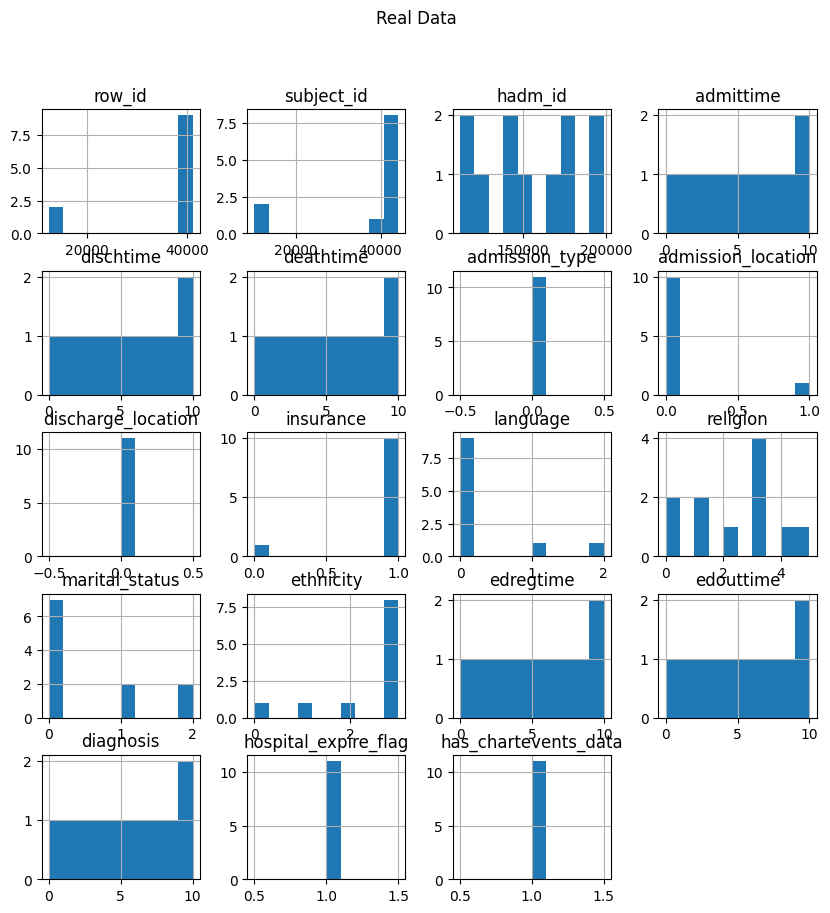

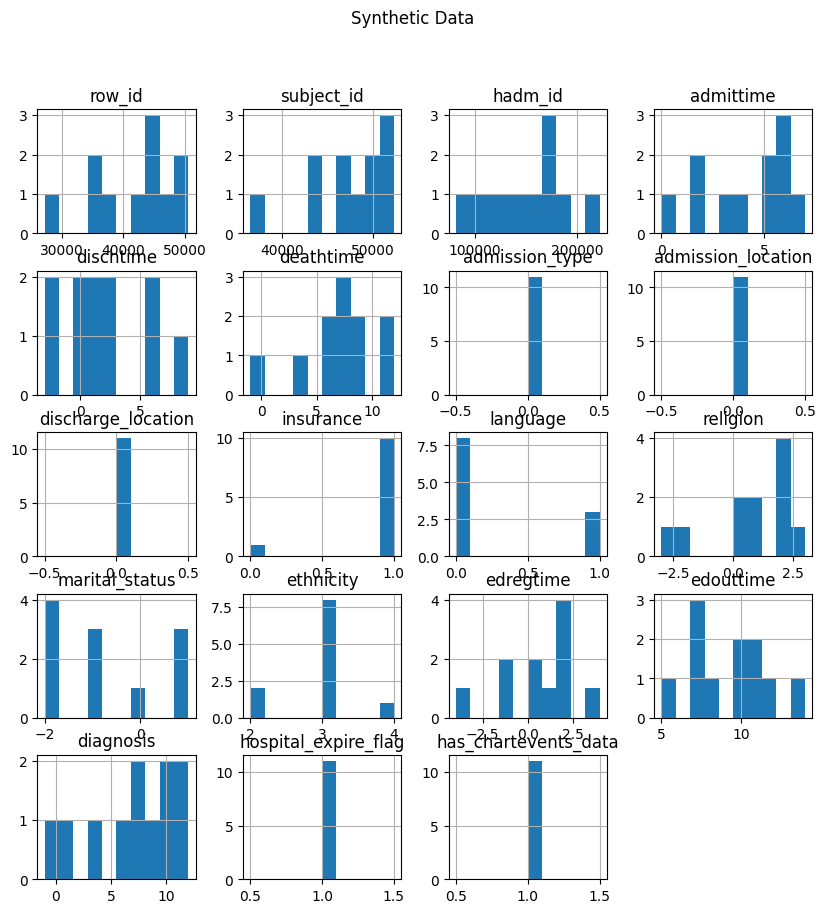

In [27]:
df.hist(figsize=(10,10))
plt.suptitle("Real Data")
plt.show()

synthetic_data.hist(figsize=(10,10))
plt.suptitle("Synthetic Data")
plt.show()

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

target = df.columns[-1]

# Train on real
model_real = RandomForestClassifier()
model_real.fit(train_data.drop(columns=[target]), train_data[target])

# Test on synthetic
pred = model_real.predict(synthetic_data.drop(columns=[target]))
print("Accuracy on Synthetic:", accuracy_score(synthetic_data[target], pred))

Accuracy on Synthetic: 1.0


In [29]:
synthetic_data.to_csv("synthetic_data.csv", index=False)

In [31]:
from google.colab import files
files.download("synthetic_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
!pip install sdv ctgan opacus pandas numpy scikit-learn matplotlib

In [33]:
import pandas as pd
import numpy as np
import torch

from ctgan import CTGAN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
from opacus import PrivacyEngine

In [34]:
df = pd.read_csv("/content/structured_medical_records.csv")


In [35]:
df.head()

,subject_id,hadm_id,adm_date,adm_time,medical_report
0,10076,198503,2107-03-21,17:50:00,Patient ID: 10076\n Admission Date: 2107-03...
1,10076,198503,2107-03-22,06:10:00,Patient ID: 10076\n Admission Date: 2107-03...
2,10076,198503,2107-03-23,06:45:00,Patient ID: 10076\n Admission Date: 2107-03...
3,10076,198503,2107-03-23,17:18:00,Patient ID: 10076\n Admission Date: 2107-03...
4,10076,198503,2107-03-24,03:39:00,Patient ID: 10076\n Admission Date: 2107-03...


In [36]:
df = df.dropna()

label_encoders = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

print(df.shape)

(408, 5)


In [37]:
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

In [38]:
ctgan = CTGAN(epochs=50, batch_size=500)
ctgan.fit(train_data)

print("GAN Training Done")

GAN Training Done


In [39]:
synthetic_data = ctgan.sample(len(df))
synthetic_data.head()

,subject_id,hadm_id,adm_date,adm_time,medical_report
0,10796,187996,-27,196,17
1,43099,185034,0,254,362
2,43169,159580,-21,220,340
3,10854,181953,5,240,265
4,40960,187609,100,182,113


In [40]:
tensor_data = torch.tensor(train_data.values, dtype=torch.float32)

train_loader = torch.utils.data.DataLoader(tensor_data, batch_size=64, shuffle=True)

model = torch.nn.Sequential(
    torch.nn.Linear(df.shape[1], 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, df.shape[1])
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

privacy_engine = PrivacyEngine()

model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=1.0,
    max_grad_norm=1.0,
)

for epoch in range(5):
    for batch in train_loader:
        optimizer.zero_grad()
        output = model(batch)
        loss = ((output - batch) ** 2).mean()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 5280329728.0
Epoch 2, Loss: 4311217664.0
Epoch 3, Loss: 4572171264.0
Epoch 4, Loss: 3617575424.0
Epoch 5, Loss: 3292318464.0


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_582/1405015169.py:28: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


In [41]:
print("Real Mean:\n", df.mean())
print("\nSynthetic Mean:\n", synthetic_data.mean())

Real Mean:
 subject_id         28576.737745
hadm_id           165548.071078
adm_date              59.926471
adm_time             166.860294
medical_report       203.500000
dtype: float64

Synthetic Mean:
 subject_id         35164.968137
hadm_id           169736.497549
adm_date              23.291667
adm_time             210.681373
medical_report       216.291667
dtype: float64


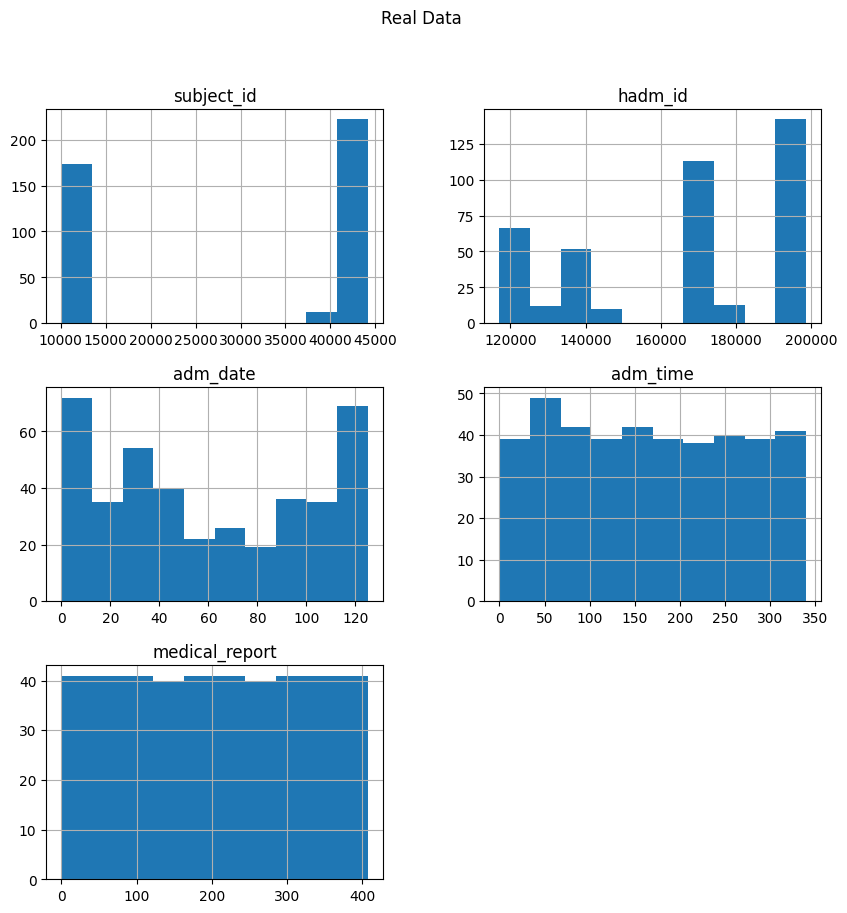

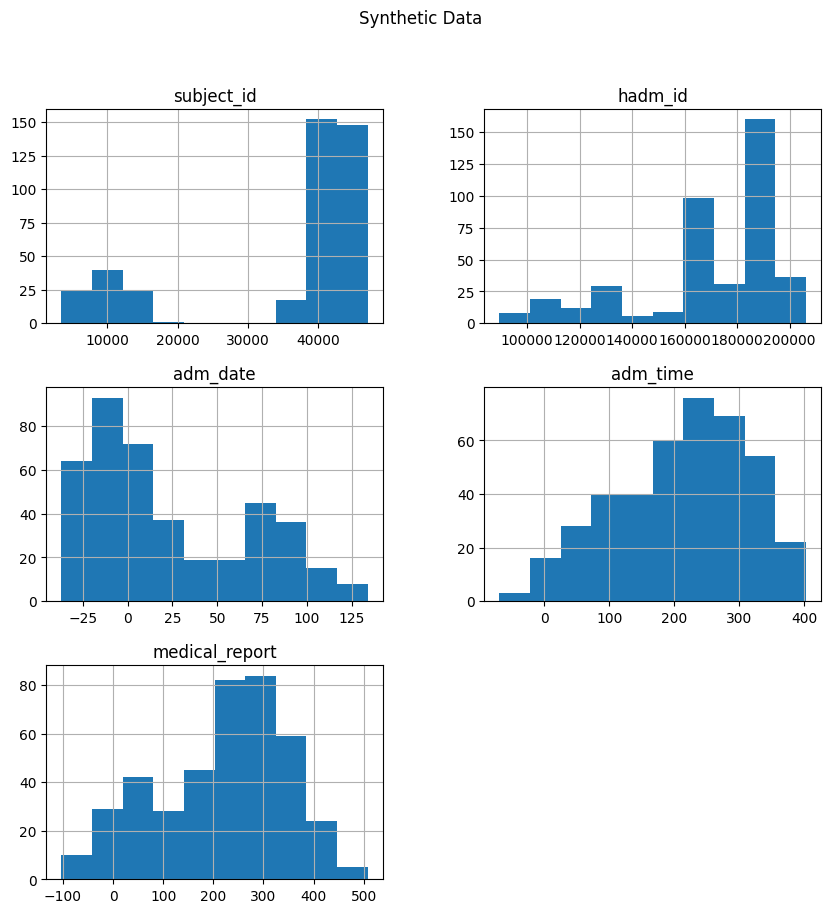

In [42]:
df.hist(figsize=(10,10))
plt.suptitle("Real Data")
plt.show()

synthetic_data.hist(figsize=(10,10))
plt.suptitle("Synthetic Data")
plt.show()

In [43]:
target = df.columns[-1]

model_real = RandomForestClassifier()
model_real.fit(train_data.drop(columns=[target]), train_data[target])

pred = model_real.predict(synthetic_data.drop(columns=[target]))

print("Accuracy:", accuracy_score(synthetic_data[target], pred))

Accuracy: 0.004901960784313725


In [44]:
synthetic_data.to_csv("synthetic_data.csv", index=False)


In [45]:
from google.colab import files
files.download("synthetic_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>